## Import Libraries

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

import warnings
warnings.filterwarnings('ignore')

## Import Dataset

In [2]:
df = pd.read_csv('Loan_default.csv',index_col=0)
df

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
LoanID,,,,,,,,,,,,,,,,,
I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0


## Data Understanding

In [3]:
df.shape

(255347, 17)

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 255347 entries, I38PQUQS96 to ZTH91CGL0B
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  str    
 10  EmploymentType  255347 non-null  str    
 11  MaritalStatus   255347 non-null  str    
 12  HasMortgage     255347 non-null  str    
 13  HasDependents   255347 non-null  str    
 14  LoanPurpose     255347 non-null  str    
 15  HasCoSigner     255347 non-null  str    
 16  Default         255347 non-null  int64  
dtypes: float64(2)

In [5]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [6]:
df.describe(include=object)

,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255347,255347,255347,255347,255347,255347,255347
unique,4,4,3,2,2,5,2
top,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,64366,64161,85302,127677,127742,51298,127701


## Data Cleaning

In [7]:
df.isna().sum()

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

<Axes: xlabel='Default', ylabel='count'>

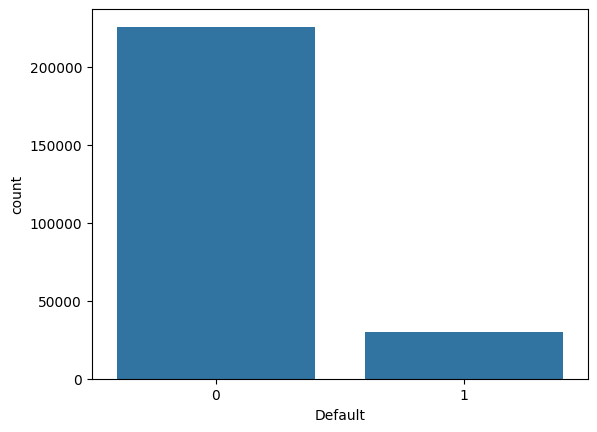

In [9]:
sns.countplot(x='Default', data=df)

<Axes: >

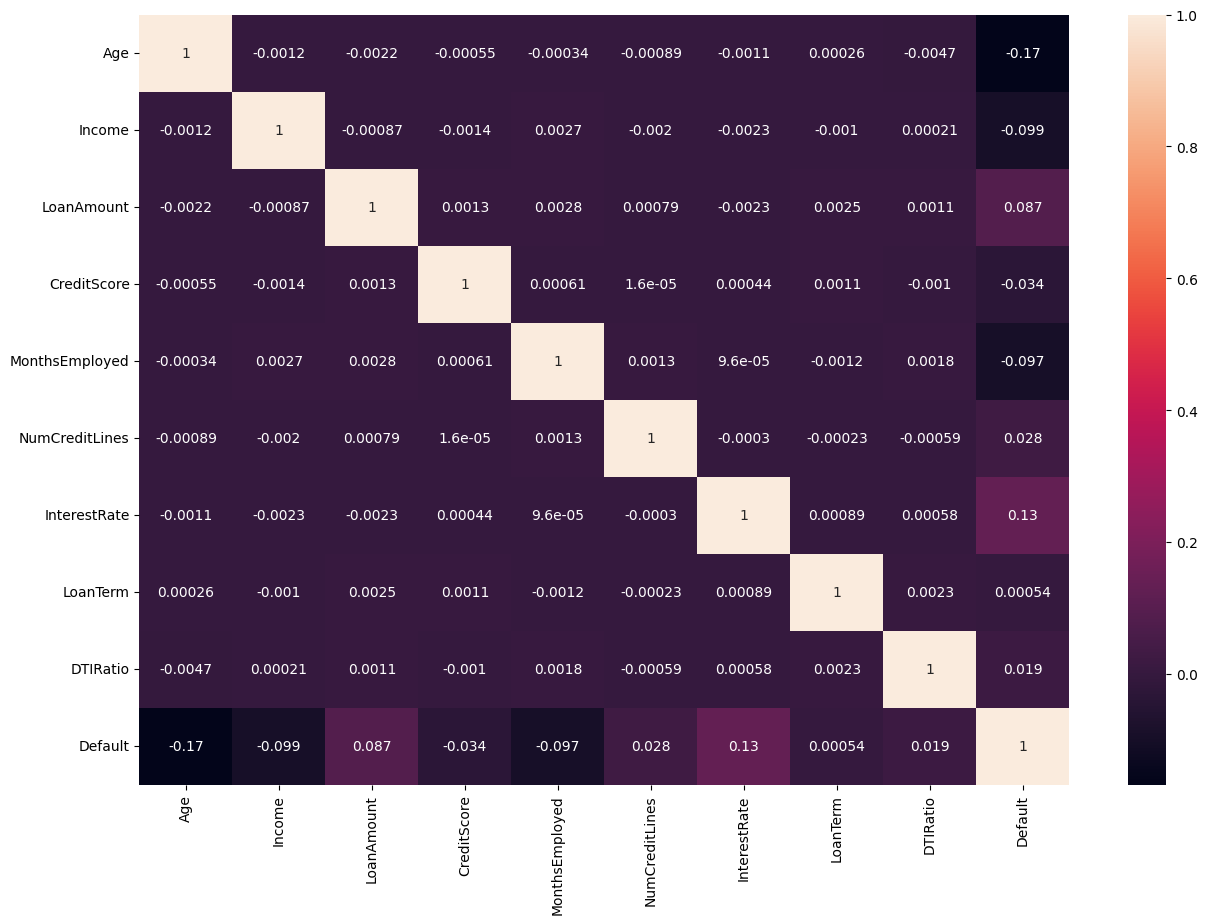

In [10]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: >

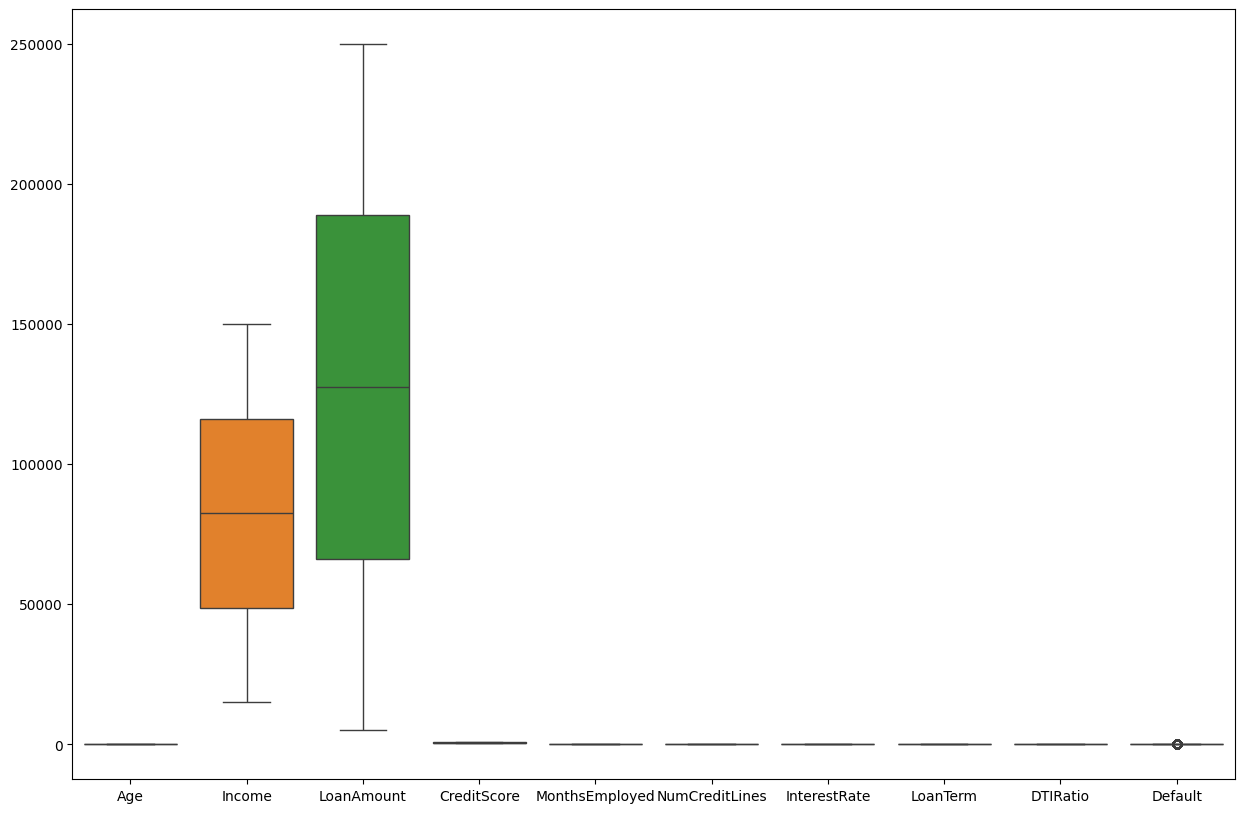

In [15]:
plt.figure(figsize=(15,10))
sns.boxplot(df)

In [25]:
corr = df.corr(numeric_only=True)

corr['Default'].sort_values(ascending=False)

Default              1.000000
loan_income_ratio    0.178963
InterestRate         0.131273
LoanAmount           0.086659
NumCreditLines       0.028330
DTIRatio             0.019236
LoanTerm             0.000545
CreditScore         -0.034166
MonthsEmployed      -0.097374
Income              -0.099119
Age                 -0.167783
Name: Default, dtype: float64

## Feature Engineering

In [16]:
df['loan_income_ratio'] = df['LoanAmount']/df['Income']

## Feature Selection

In [17]:
X = df.drop('Default', axis=1)
y = df['Default']

In [22]:
# Train test split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [24]:
cat_features = df.select_dtypes(include=object).columns.to_list()
cat_features

['Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner']

## Model Building

In [27]:
model = CatBoostClassifier(random_state=42,auto_class_weights='Balanced',verbose=100)

In [28]:
model.fit(X_train,y_train,cat_features=cat_features)

Learning rate set to 0.099861
0:	learn: 0.6782664	total: 447ms	remaining: 7m 26s
100:	learn: 0.5842229	total: 16.6s	remaining: 2m 27s
200:	learn: 0.5750577	total: 31.2s	remaining: 2m 4s
300:	learn: 0.5669372	total: 47s	remaining: 1m 49s
400:	learn: 0.5591108	total: 1m 2s	remaining: 1m 33s
500:	learn: 0.5515778	total: 1m 18s	remaining: 1m 18s
600:	learn: 0.5445157	total: 1m 40s	remaining: 1m 7s
700:	learn: 0.5379933	total: 2m	remaining: 51.6s
800:	learn: 0.5313929	total: 2m 19s	remaining: 34.8s
900:	learn: 0.5250817	total: 2m 38s	remaining: 17.4s
999:	learn: 0.5193025	total: 2m 57s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=100)

## Make Predictions

In [30]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

## Evaluate the Model

In [33]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_proba))

Accuracy : 0.7118073232817701
Precision: 0.23309640969564424
Recall   : 0.6469398077895802
F1 Score : 0.34271168274383706
ROC AUC  : 0.7487449107584128


In [34]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[32515 12624]
 [ 2094  3837]]


In [35]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.72      0.82     45139
           1       0.23      0.65      0.34      5931

    accuracy                           0.71     51070
   macro avg       0.59      0.68      0.58     51070
weighted avg       0.86      0.71      0.76     51070



In [36]:
## Check Baseline Without Class Weights
model = CatBoostClassifier(random_state=42,verbose=0)

In [37]:
model.fit(X_train,y_train,cat_features=cat_features)

CatBoostClassifier(random_state=42, verbose=0)

In [38]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [39]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_proba))

Accuracy : 0.8858037987076561
Precision: 0.5608856088560885
Recall   : 0.0768841679312089
F1 Score : 0.13523131672597866
ROC AUC  : 0.7539956880750474


In [40]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[44782   357]
 [ 5475   456]]


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.56      0.08      0.14      5931

    accuracy                           0.89     51070
   macro avg       0.73      0.53      0.54     51070
weighted avg       0.85      0.89      0.85     51070



## Hyperparameters tuning

In [43]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'iterations': [200, 500, 1000],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

rscv = RandomizedSearchCV(
    estimator=CatBoostClassifier(
        task_type="GPU",
        devices='0',
        random_state=42,
        verbose=0
    ),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=1,
    verbose=2
)

rscv.fit(X_train, y_train, cat_features=cat_features)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END depth=4, iterations=500, l2_leaf_reg=3, learning_rate=0.05; total time=  11.2s
[CV] END depth=4, iterations=500, l2_leaf_reg=3, learning_rate=0.05; total time=   8.7s
[CV] END depth=4, iterations=500, l2_leaf_reg=3, learning_rate=0.05; total time=   8.9s
[CV] END depth=4, iterations=1000, l2_leaf_reg=9, learning_rate=0.01; total time=  17.6s
[CV] END depth=4, iterations=1000, l2_leaf_reg=9, learning_rate=0.01; total time=  19.1s
[CV] END depth=4, iterations=1000, l2_leaf_reg=9, learning_rate=0.01; total time=  18.9s
[CV] END depth=10, iterations=500, l2_leaf_reg=3, learning_rate=0.01; total time=  53.0s
[CV] END depth=10, iterations=500, l2_leaf_reg=3, learning_rate=0.01; total time=  52.9s
[CV] END depth=10, iterations=500, l2_leaf_reg=3, learning_rate=0.01; total time=  52.8s
[CV] END depth=6, iterations=1000, l2_leaf_reg=3, learning_rate=0.01; total time=  29.8s
[CV] END depth=6, iterations=1000, l2_leaf_reg=3, le

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostClass...U', verbose=0)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'depth': [4, 6, ...], 'iterations': [200, 500, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.01, 0.05, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versioncha

In [44]:
print("Best Params:", rscv.best_params_)
print("Best CV Score:", rscv.best_score_)

Best Params: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 4}
Best CV Score: 0.7545416860425361


In [48]:
best_model = rscv.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [46]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8868024280399451
Precision: 0.614329268292683
Recall   : 0.06794806946552015
F1 Score : 0.12236222863215425
ROC AUC  : 0.7609303963464225


In [ ]:
for t in [0.10, 0.15, 0.20, 0.25, 0.30]:
    y_pred = (y_prob >= t).astype(int)
    print(
        f"Threshold={t}",
        f"F1={f1_score(y_test, y_pred):.4f}"
    )

Threshold=0.1 F1=0.3277
Threshold=0.15 F1=0.3675
Threshold=0.2 F1=0.3750
Threshold=0.25 F1=0.3514
Threshold=0.3 F1=0.3139


In [49]:
y_prob = best_model.predict_proba(X_test)[:,1]

y_pred_final = (y_prob >= 0.2).astype(int)

## Feature Importance 

In [51]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
0,Age,30.783508
6,InterestRate,21.278864
16,loan_income_ratio,18.177302
4,MonthsEmployed,11.836507
3,CreditScore,2.554391
10,EmploymentType,2.553684
15,HasCoSigner,1.894770
13,HasDependents,1.783544
5,NumCreditLines,1.452001
8,DTIRatio,1.403260


In [53]:
!pip install shap

   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 360.5 kB/s  0:00:01
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.5/41.9 MB 730.2 kB/s eta 0:00:57
    --------------------------------------- 0.5/41.9 MB 7

In [54]:
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

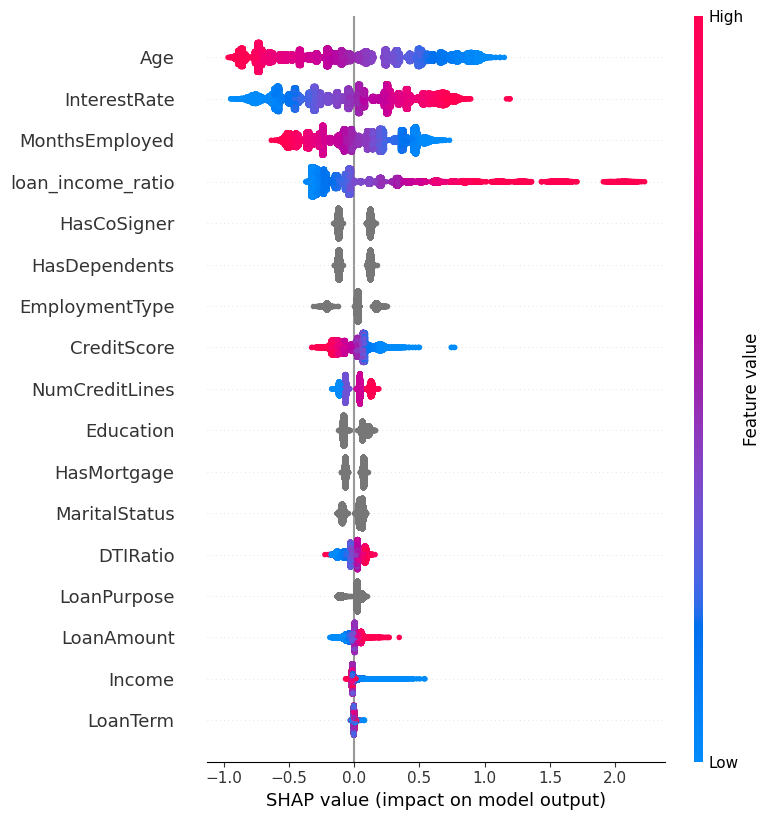

In [55]:
shap.summary_plot(
    shap_values,
    X_test
)

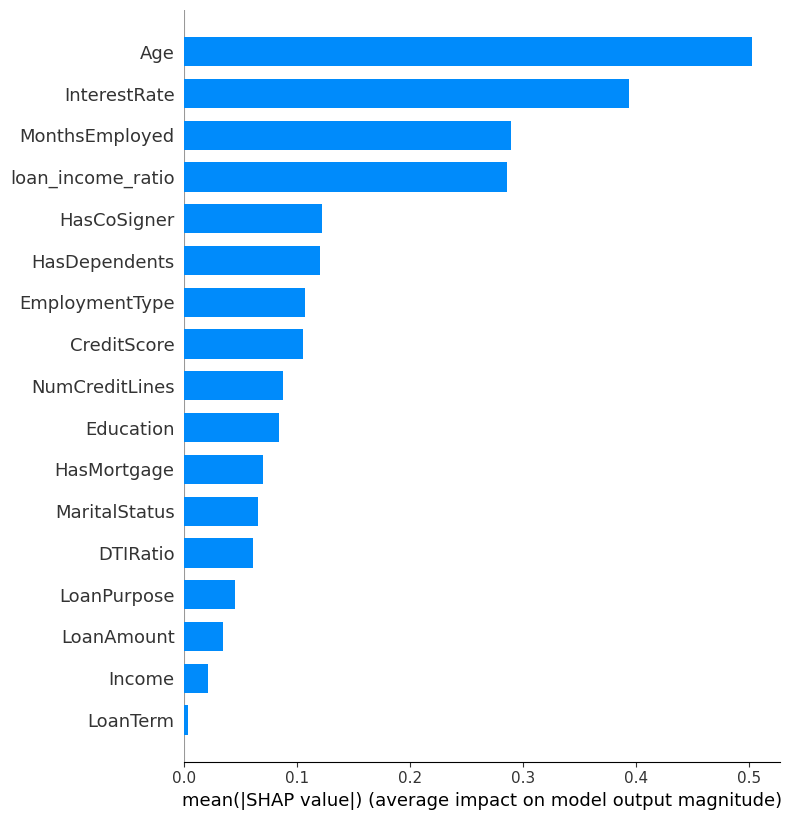

In [56]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

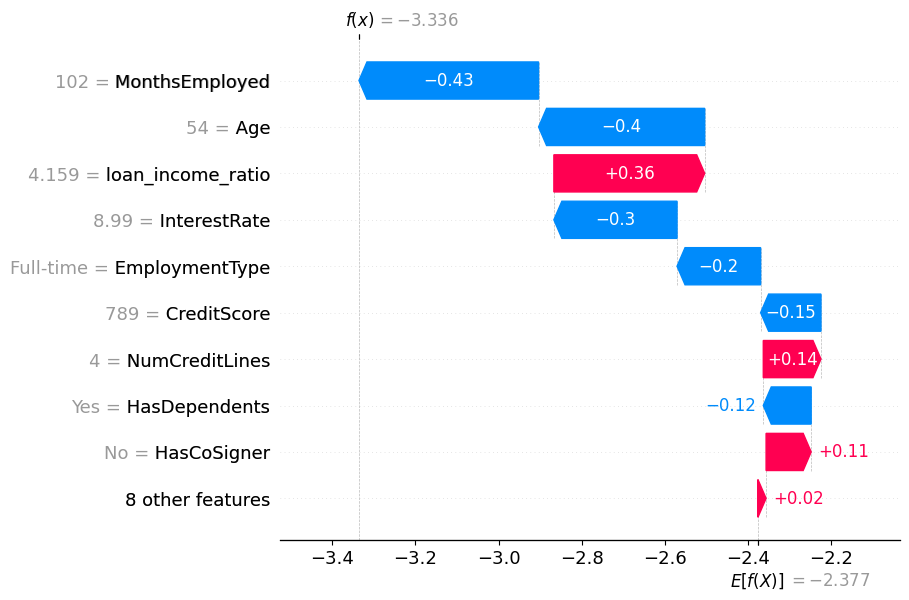

In [58]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

## Save the Final Model

In [62]:
import joblib

joblib.dump(best_model, 'loan_default_catboost.pkl')

print("Model saved successfully!")

Model saved successfully!


## Load Model 

In [63]:
model = joblib.load('loan_default_catboost.pkl')

print("Model loaded successfully!")

Model loaded successfully!


In [66]:
y_prob = model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= 0.20).astype(int)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(51070,))

In [67]:
joblib.dump(cat_features, 'cat_features.pkl')
joblib.dump(0.20, 'best_threshold.pkl')

['best_threshold.pkl']

In [68]:
cat_features = joblib.load('cat_features.pkl')
best_threshold = joblib.load('best_threshold.pkl')

## Conclusion

This project focused on predicting loan defaults using demographic, employment, financial, and credit-related information. The dataset contained both numerical and categorical features, making CatBoost a suitable choice due to its native handling of categorical variables with minimal preprocessing.

The data was cleaned, explored, and prepared through exploratory data analysis and feature engineering. A CatBoost Classifier was trained and further optimized using RandomizedSearchCV to improve predictive performance. The final model achieved a ROC-AUC score of 0.761, indicating a good ability to distinguish between borrowers who are likely to default and those who are not.

To improve the detection of loan defaulters, threshold tuning was performed on the predicted probabilities. By reducing the classification threshold from 0.50 to 0.20, the F1 Score improved substantially, demonstrating the importance of threshold optimization in imbalanced classification problems.

Feature importance analysis and SHAP-based interpretability provided insights into the key drivers of loan default risk, including Credit Score, Debt-to-Income Ratio, Interest Rate, Income, and Loan Amount. These findings can help financial institutions better understand borrower risk and support more informed lending decisions.

Overall, this project demonstrates a complete machine learning workflow including data preprocessing, model training, hyperparameter tuning, threshold optimization, model evaluation, and explainable AI techniques for credit risk assessment.
